In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

In [5]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


We are dealing with circular data such as column 'day' and 'wind direction'. We want to transform them using sin() and cos() functions. This helps capture the cyclical relationship in a continuous way, ensuring that values at the “ends” of the cycle are close together.

In [6]:
df_train['day'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

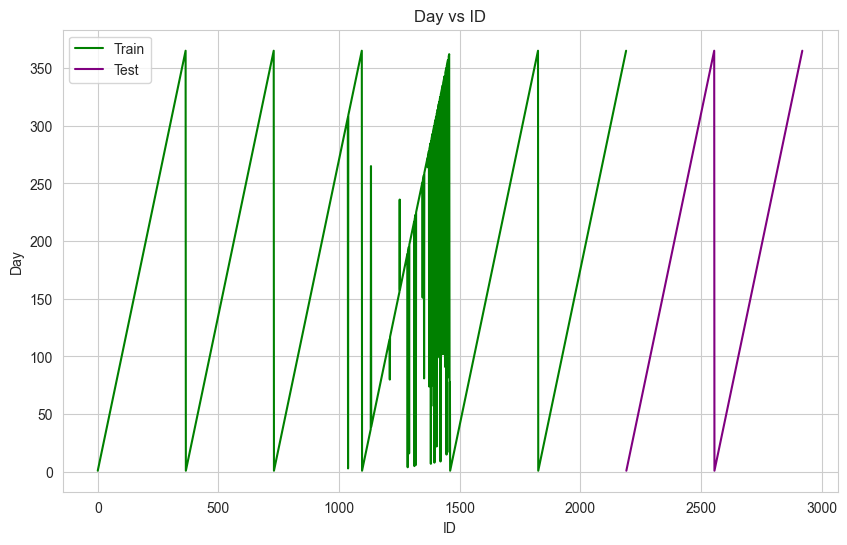

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

We were expecting a circular pattern in the plot above. We can see that the days are not in order, but we can see that the pattern is cyclical. We can repair this by transforming the 'day' column.

In [8]:
# Transform day column so that id matches the day
df_train['day_repaired'] = df_train['id'] % 365

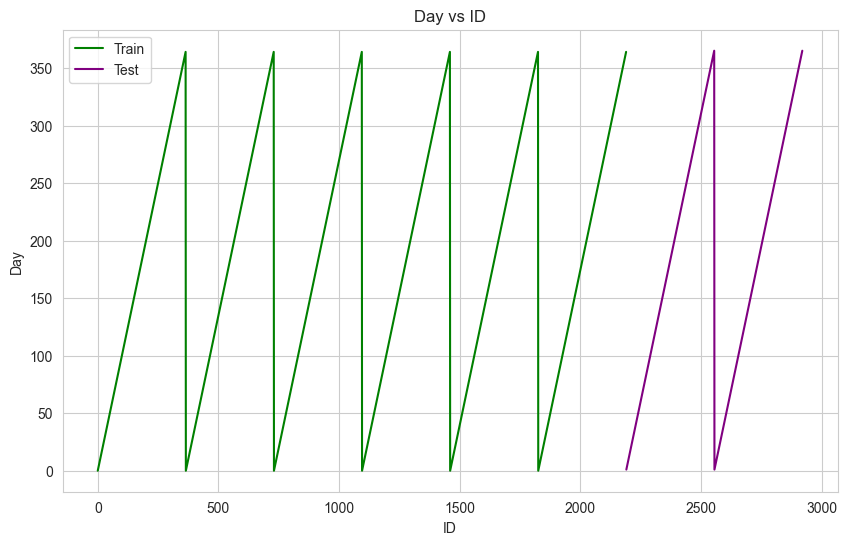

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day_repaired'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

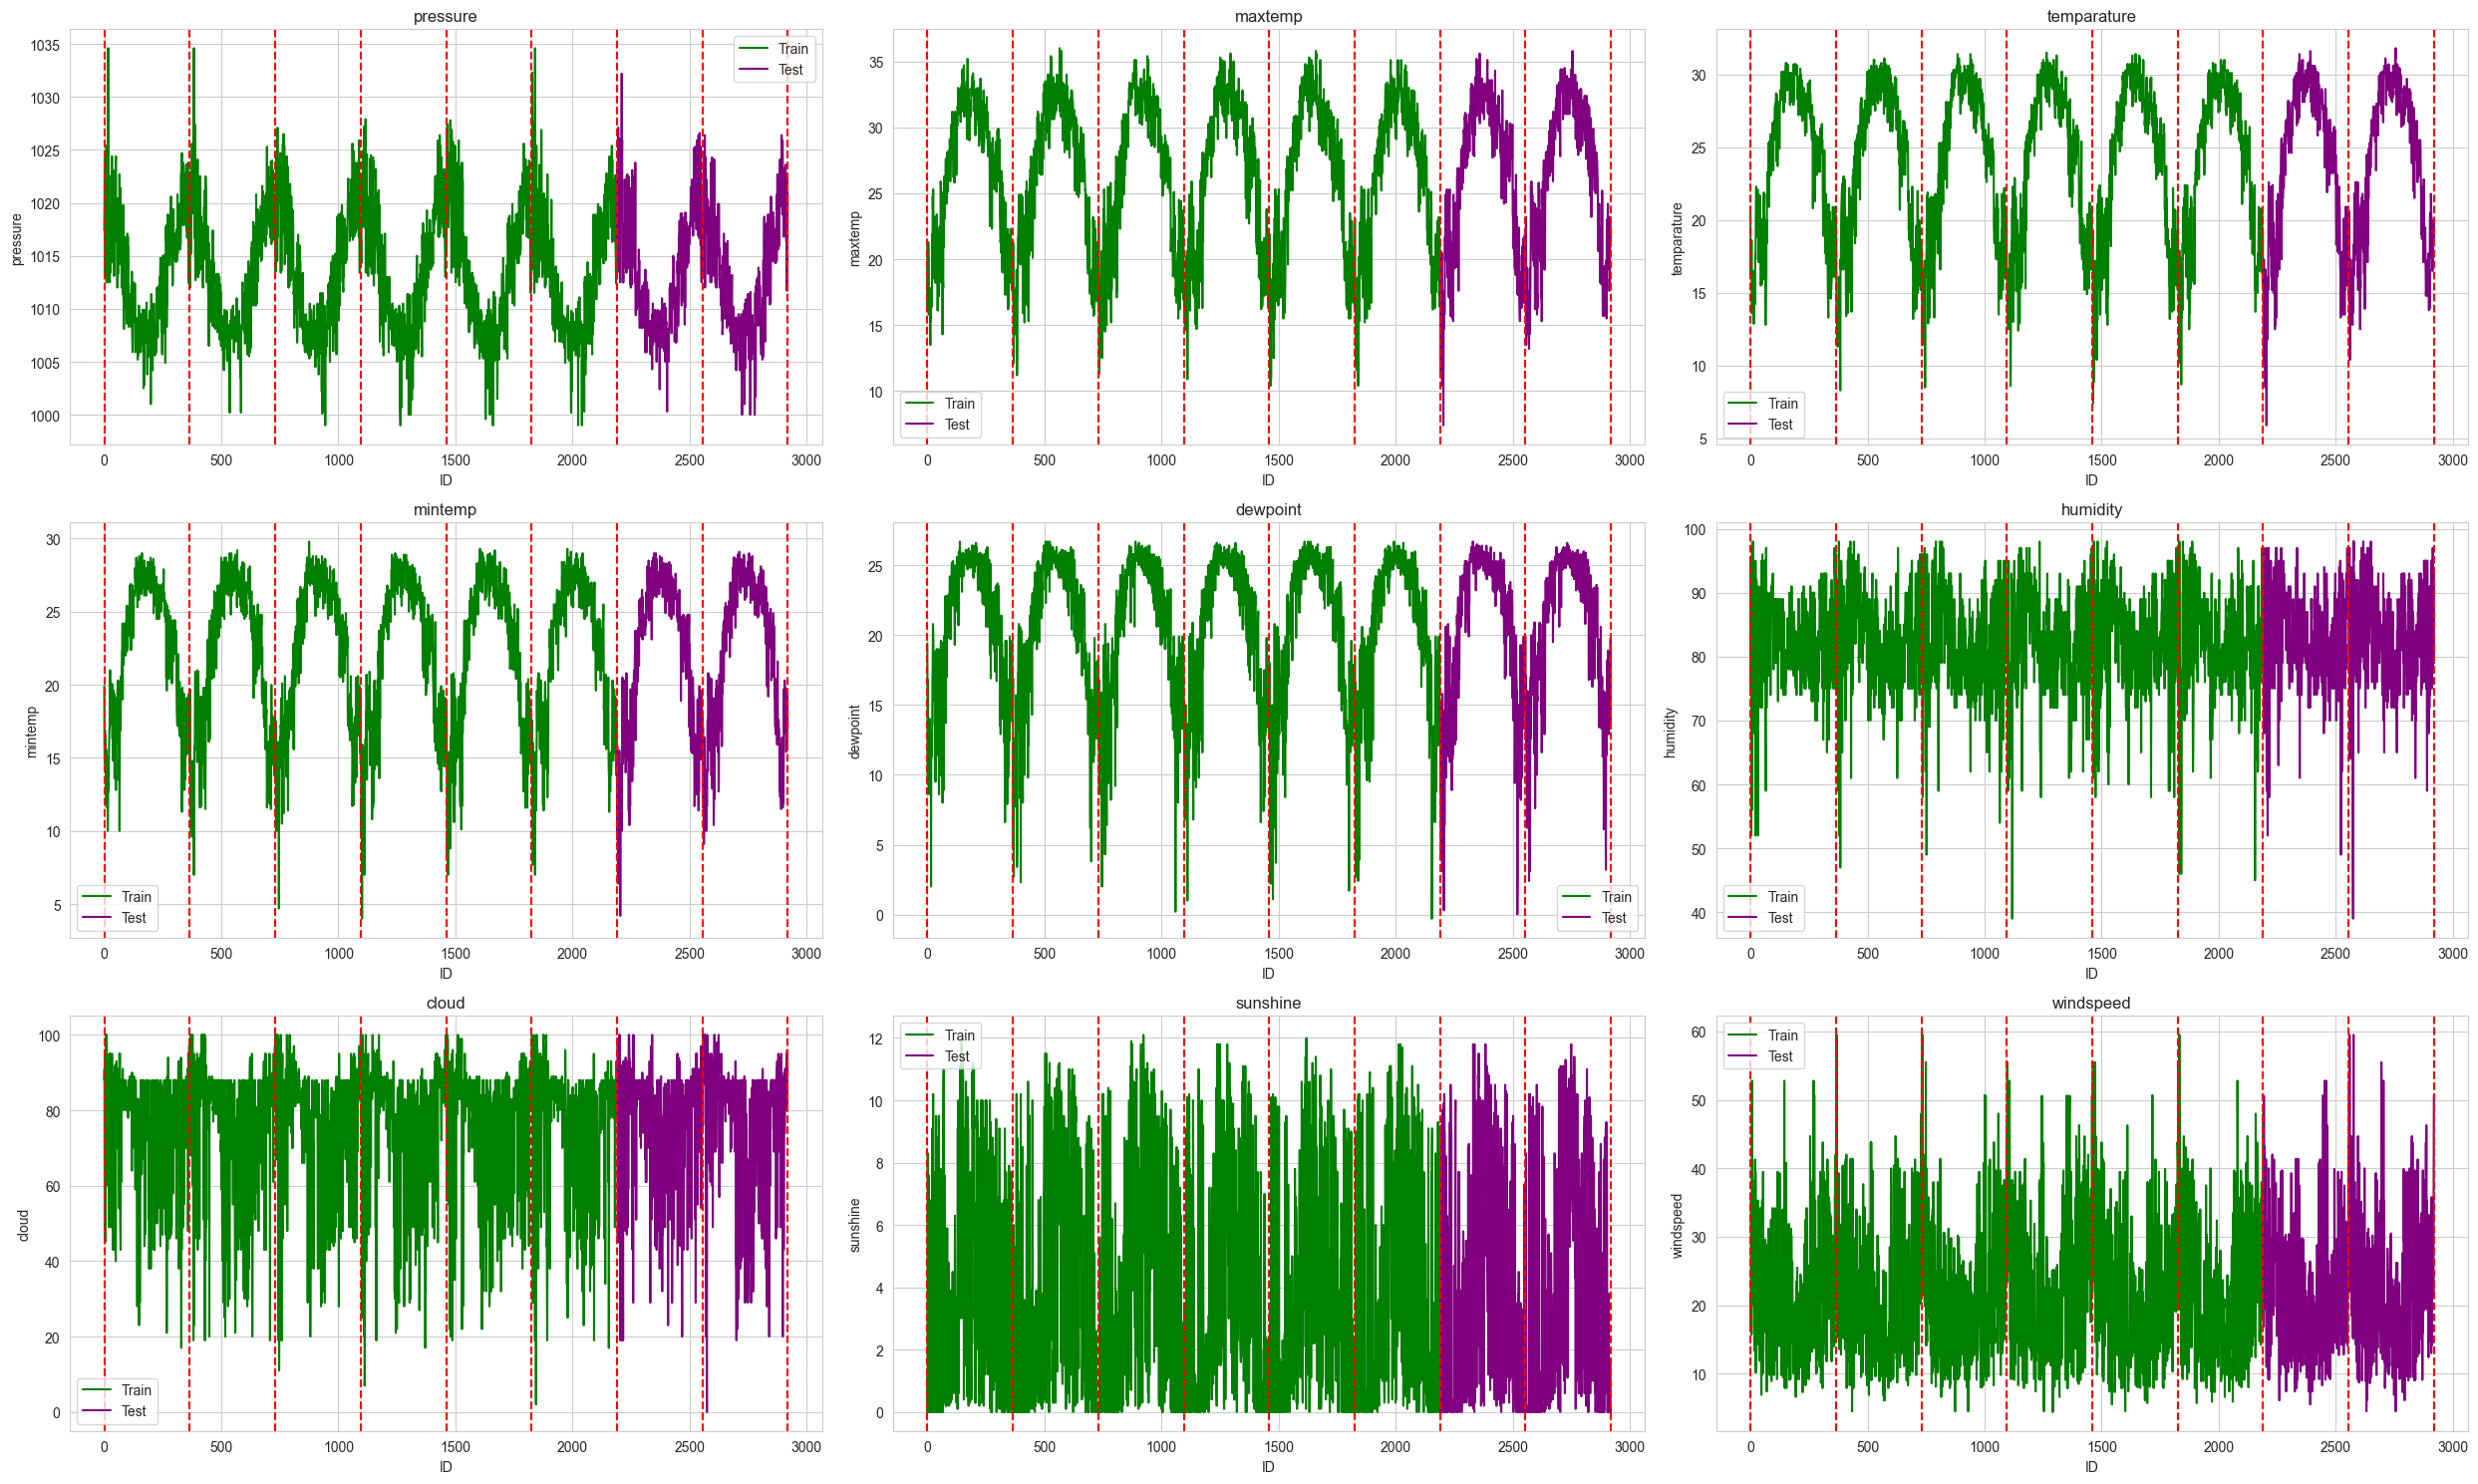

In [10]:
feature_list = [item for item in df_train.columns if item not in ['id', 'day', 'day_repaired', 'rainfall', 'winddirection']]

fig, axes = plt.subplots(3, 3, figsize=(25, 15))
axes = axes.flatten()
lines = [x for x in range(0, max(df_test['id']) + 364, 365)]
for i, feature in enumerate(feature_list):
    axes[i].plot(df_train['id'], df_train[feature], color='green')
    axes[i].plot(df_test['id'], df_test[feature], color='purple')
    for x in lines:
        axes[i].axvline(x=x, color='red', linestyle='--')
    axes[i].set_title(feature)
    axes[i].set_xlabel('ID')
    axes[i].set_ylabel(feature)
    axes[i].legend(['Train', 'Test'])

plt.tight_layout()
plt.show()

We see that the pattern is cyclical. Now we can transform the 'day' column.

In [11]:
def transform_circular(data, column):
    new_data = data.copy()
    new_data[column + '_sin'] = np.sin(2 * np.pi * new_data[column] / max(new_data[column]))
    new_data[column + '_cos'] = np.cos(2 * np.pi * new_data[column] / max(new_data[column]))
    return new_data

In [12]:
train = transform_circular(df_train, 'day_repaired')
train = transform_circular(train, 'winddirection')
train.drop(['id', 'day', 'day_repaired', 'winddirection'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,day_repaired_sin,day_repaired_cos,winddirection_sin,winddirection_cos
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,0.000000,1.000000,0.951057,0.309017
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,0.017261,0.999851,0.866025,0.500000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,0.034516,0.999404,0.994522,0.104528
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,0.051761,0.998659,0.951057,0.309017
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,0.068991,0.997617,0.743145,0.669131


Ostateczna wersja danych to 'train'.

## Combinations of columns

In [16]:
import itertools

In [17]:
def generate_combinations(df, exclude_columns=[]):
    selected_columns = [col for col in df.columns if col not in exclude_columns]

    new_columns = {}
    
    for n in range(2, 3):
        for cols in itertools.combinations(selected_columns, n):
            col_combination = '_'.join(cols)
    
            # Addition
            new_columns[f'{col_combination}_plus'] = df[list(cols)].sum(axis=1)
    
            # Subtraction
            if n == 2:
                new_columns[f'{cols[0]}_minus_{cols[1]}'] = df[cols[0]] - df[cols[1]]
                new_columns[f'{cols[1]}_minus_{cols[0]}'] = df[cols[1]] - df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_minus_{pair[1]}'] = df[pair[0]] - df[pair[1]]
                    new_columns[f'{pair[1]}_minus_{pair[0]}'] = df[pair[1]] - df[pair[0]]
    
            # Multiplication
            new_columns[f'{col_combination}_times'] = df[list(cols)].prod(axis=1)
    
            # Division
            if n == 2:
                new_columns[f'{cols[0]}_div_{cols[1]}'] = df[cols[0]] / df[cols[1]]
                new_columns[f'{cols[1]}_div_{cols[0]}'] = df[cols[1]] / df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_div_{pair[1]}'] = df[pair[0]] / df[pair[1]]
                    new_columns[f'{pair[1]}_div_{pair[0]}'] = df[pair[1]] / df[pair[0]]
    
    df_new = pd.DataFrame(new_columns, index=df.index)
    
    df_comb = pd.concat([df, df_new], axis=1)
    df_comb.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_comb.fillna(0, inplace=True)
    return df_comb

In [18]:
train_combinations = generate_combinations(train, exclude_columns=['rainfall'])
train_combinations.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,...,winddirection_cos_minus_day_repaired_cos,day_repaired_cos_winddirection_cos_times,day_repaired_cos_div_winddirection_cos,winddirection_cos_div_day_repaired_cos,winddirection_sin_winddirection_cos_plus,winddirection_sin_minus_winddirection_cos,winddirection_cos_minus_winddirection_sin,winddirection_sin_winddirection_cos_times,winddirection_sin_div_winddirection_cos,winddirection_cos_div_winddirection_sin
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,...,-0.690983,0.309017,3.236068,0.309017,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,...,-0.499851,0.499926,1.999702,0.500074,1.366025,0.366025,-0.366025,0.433013,1.732051,0.577350
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,...,-0.894876,0.104466,9.561072,0.104591,1.099050,0.889993,-0.889993,0.103956,9.514364,0.105104
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,...,-0.689642,0.308603,3.231730,0.309432,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,...,-0.328487,0.667536,1.490916,0.670729,1.412275,0.074014,-0.074014,0.497261,1.110613,0.900404


final data to use is 'train_combinations'